In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
df=pd.read_csv(r"C:\Users\mrhas\Downloads\heart.csv")
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


# EDA

In [14]:
df.shape

(918, 12)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [16]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [19]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [20]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

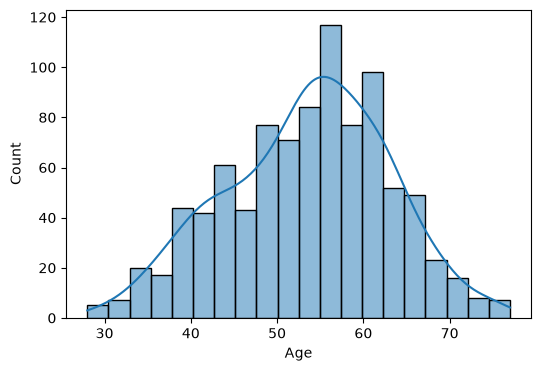

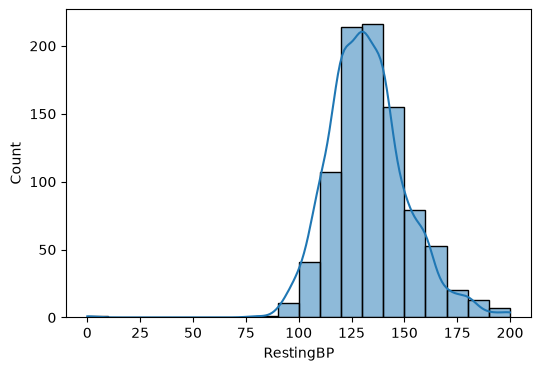

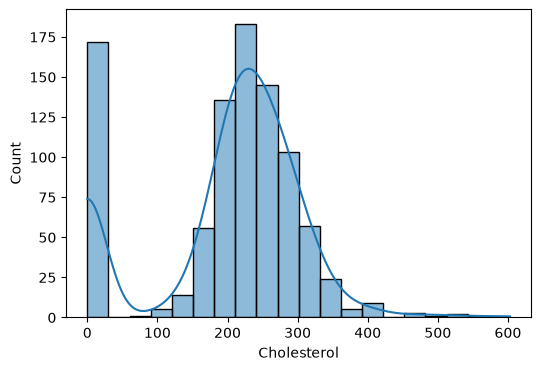

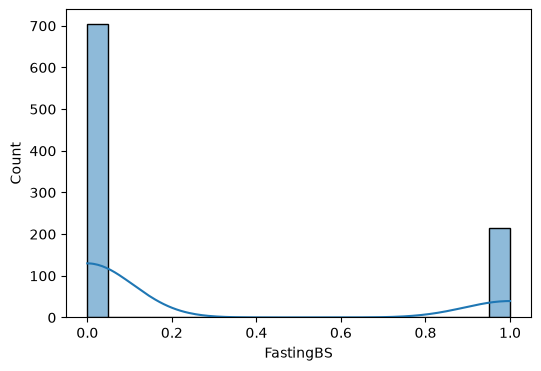

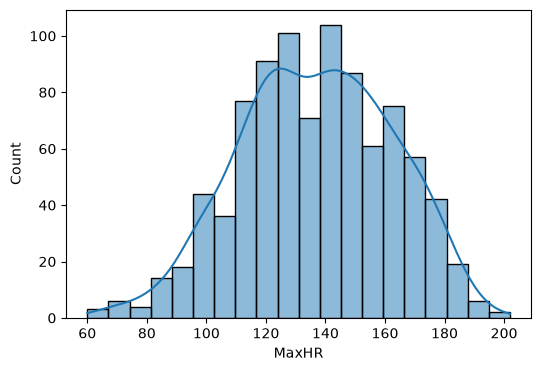

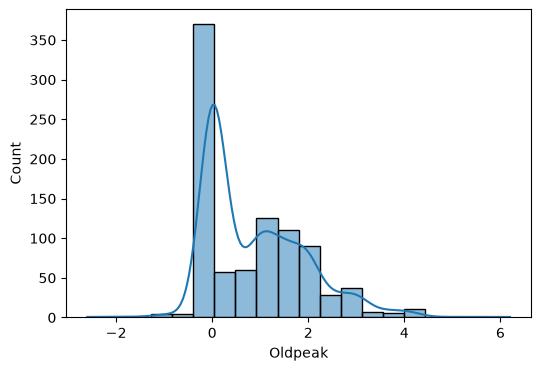

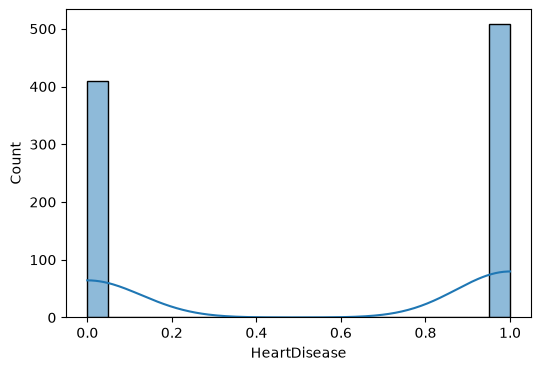

In [23]:
nume=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']
for coln in nume:
    plt.figure(figsize=(6,4))
    sns.histplot(df[coln],kde=True, bins=20)

In [28]:
ch_mean=df.loc[df["Cholesterol"]!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [29]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

In [31]:
ch_mean=df.loc[df["RestingBP"]!=0,'RestingBP'].mean()
ch_mean

np.float64(132.54089422028352)

In [32]:
df['RestingBP']=df['RestingBP'].replace(0,ch_mean)
df['RestingBP']=df['RestingBP'].round(2)

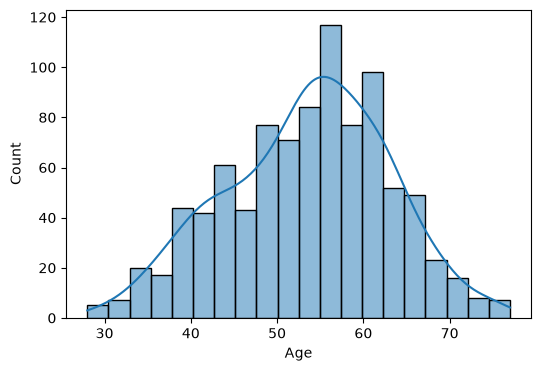

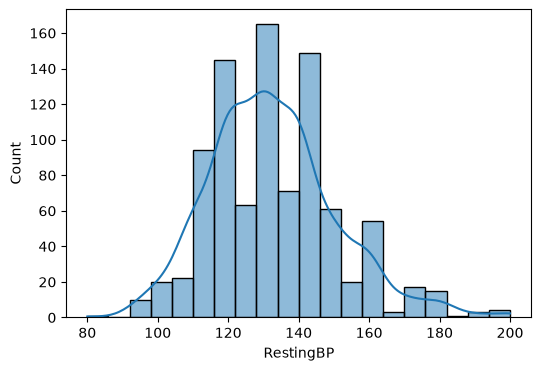

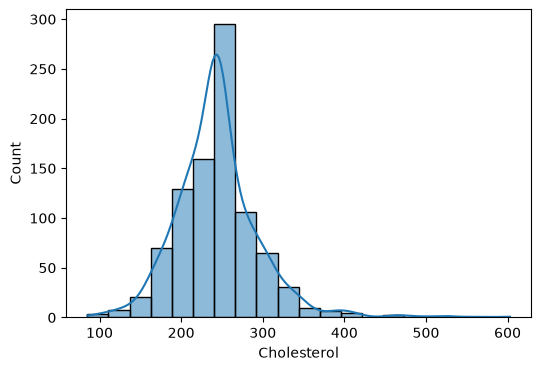

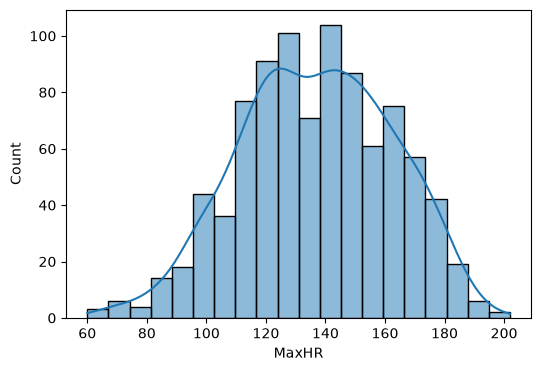

In [33]:
nume=['Age','RestingBP','Cholesterol','MaxHR']
for coln in nume:
    plt.figure(figsize=(6,4))
    sns.histplot(df[coln],kde=True, bins=20)

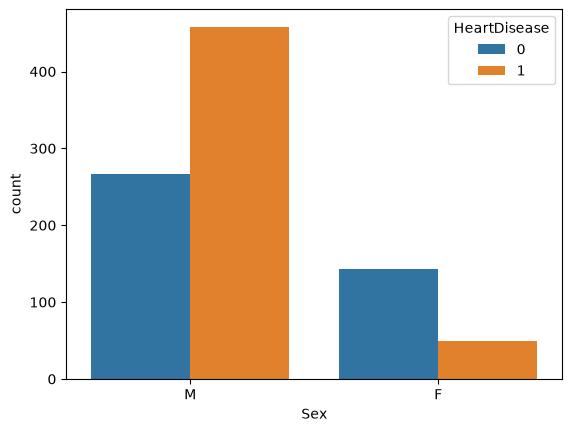

In [37]:
sns.countplot(x='Sex',data=df,hue=df['HeartDisease'])
plt.show()

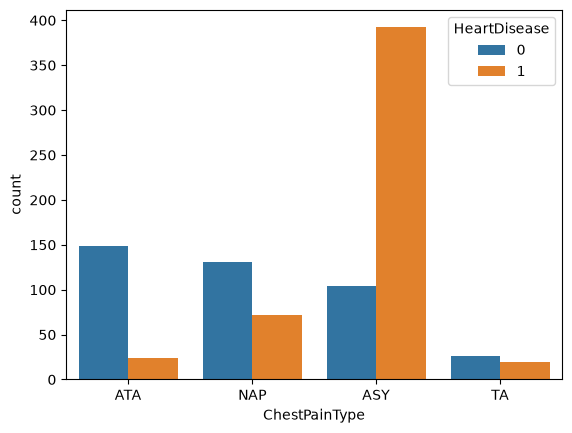

In [36]:
sns.countplot(x='ChestPainType',data=df,hue=df['HeartDisease'])
plt.show()

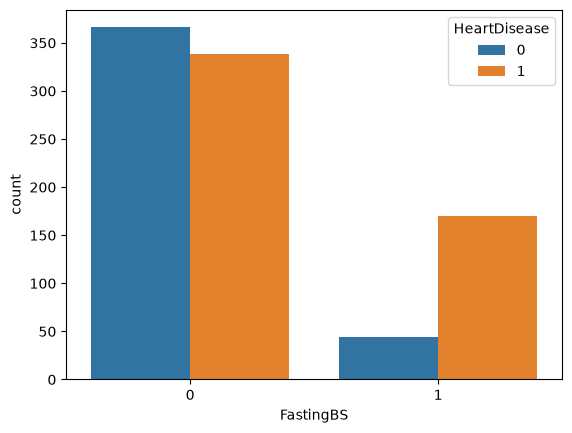

In [39]:
sns.countplot(x='FastingBS',data=df,hue=df['HeartDisease'])
plt.show()

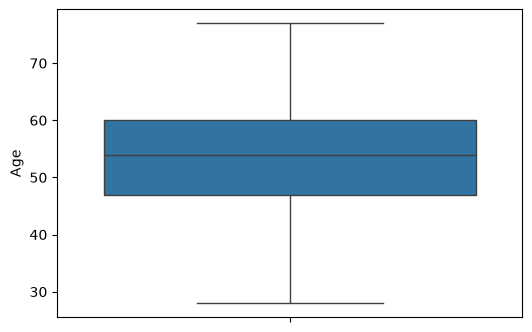

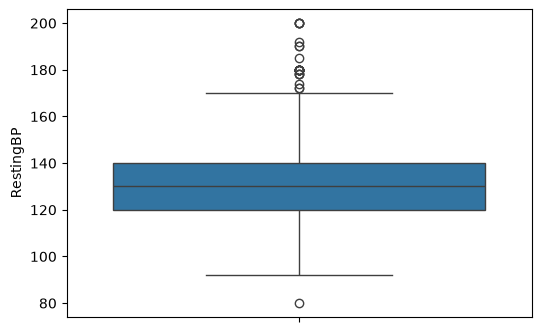

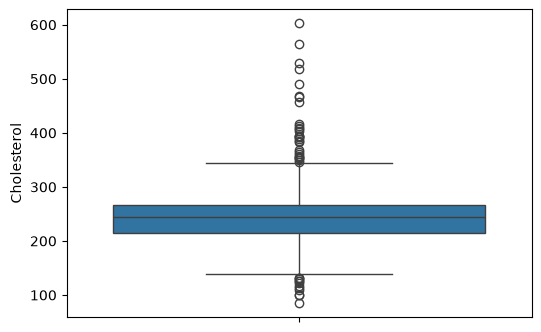

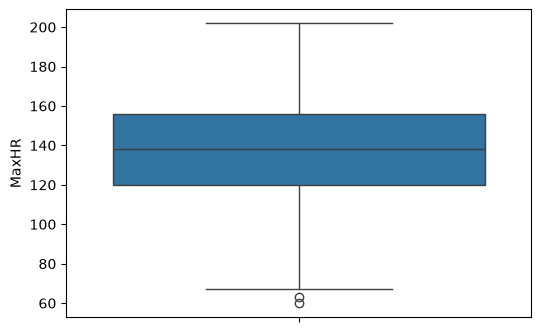

In [40]:
for coln in nume:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[coln])

# Data Cleaning & Preprocessing

In [100]:
df_cleans=df.copy()

In [101]:
df_cleans.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [102]:
df_cleans['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

# Feature Encoding

In [103]:
df_cleans['Sex'] = df_cleans['Sex'].astype('object').map({'M':0, 'F':1})

In [104]:
df_cleans.dtypes

Age                 int64
Sex                 int64
ChestPainType         str
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [105]:
df_cleans=pd.get_dummies(df_cleans,drop_first=True)

In [106]:
df_cleans=df_cleans.astype(int)

In [108]:
df_cleans.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,1,0,0,1,0,0,0,1
1,49,1,160,180,0,156,1,1,0,1,0,1,0,0,1,0
2,37,0,130,283,0,98,0,0,1,0,0,0,1,0,0,1
3,48,1,138,214,0,108,1,1,0,0,0,1,0,1,1,0
4,54,0,150,195,0,122,0,0,0,1,0,1,0,0,0,1


# Feature scaling

In [78]:
from sklearn.preprocessing import StandardScaler
col=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

In [110]:
sl=StandardScaler()
df_cleans[col]=sl.fit_transform(df_cleans[col])

In [111]:
df_cleans.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414885,0.834754,0,1.382928,-0.727592,0,1,0,0,1,0,0,0,1
1,-0.478484,1,1.527224,-1.210675,0,0.754157,0.282891,1,0,1,0,1,0,0,1,0
2,-1.751359,0,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,0,0,0,1,0,0,1
3,-0.584556,1,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,1,0,1,1,0
4,0.051881,0,0.971054,-0.929194,0,-0.581981,-0.727592,0,0,1,0,1,0,0,0,1


In [113]:
df_cleans.to_csv('final_cleaned.csv', index=False)

# MODEL TRAIN

In [116]:
X = df_cleans.drop('HeartDisease', axis=1)
y = df_cleans['HeartDisease']

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [126]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [127]:
model.score(X_test,y_test)*100

85.86956521739131

In [128]:
y_pred = model.predict(X_test)

In [130]:
import pandas as pd

new_patient = pd.DataFrame([{
    'Age': 0.2,
    'Sex': 1,
    'RestingBP': 0.5,
    'Cholesterol': -0.3,
    'FastingBS': 0,
    'MaxHR': 1.0,
    'Oldpeak': -0.2,
    'ChestPainType_ATA': 0,
    'ChestPainType_NAP': 1,
    'ChestPainType_TA': 0,
    'RestingECG_Normal': 1,
    'RestingECG_ST': 0,
    'ExerciseAngina_Y': 0,
    'ST_Slope_Flat': 1,
    'ST_Slope_Up': 0
}])

In [131]:
prediction = model.predict(new_patient)
print(prediction)

[0]


In [133]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']